<a href="https://colab.research.google.com/github/k3re/matatu-path-finder/blob/main/Nairobi_Matatu_Routes_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJECT 2: MATATU ROUTE OPTIMIZATION - NAIROBI TRANSPORT NETWORK ANALYSIS

## Smart Urban Mobility Through Graph Algorithms

**Project Team:** Urban Planning

**Location:** Nairobi, Kenya

**Date:** 2026

**Members:** Michelle, Hans

## Install and Import Libraries

In [ ]:
import sys
print(f"Python Version: {sys.version}")

# Install required packages
import subprocess
packages = ['matplotlib', 'networkx', 'pandas', 'numpy', 'seaborn', 'scikit-learn']
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

# Configure visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10

print('All libraries imported successfully')

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
All libraries imported successfully


## Problem Understanding

### Introduction

Nairobi's public transportation system relies heavily on matatus (shared minibuses) to move millions of residents daily. The city faces significant challenges in route optimization, network efficiency, and commuter experience.
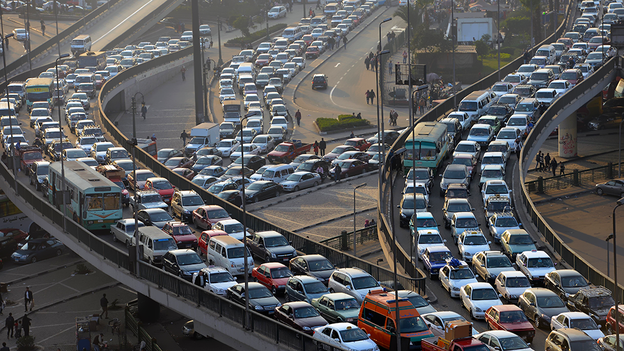

### Key Challenges

1. **Route Inefficiency:** Limited visibility into optimal paths between major stops
2. **Travel Time Variability:** Multiple possible routes with different time and distance costs
3. **Network Complexity:** Large interconnected network requiring systematic analysis
4. **Resource Allocation:** Difficulty identifying critical infrastructure points

### Solution Approach

We apply graph theory and algorithms to:
- Model the matatu network as a graph structure (stops as nodes, connections as edges)
- Implement multiple pathfinding algorithms (BFS, DFS, Dijkstra's)
- Compare algorithm performance across different scenarios
- Identify network bottlenecks and opportunities
- Provide data-driven recommendations for route optimization

### Objectives

1. Create a comprehensive graph representation of Nairobi's matatu network
2. Implement and compare three fundamental pathfinding algorithms
3. Analyze network topology and statistics
4. Visualize the transportation network
5. Provide actionable insights for commuters and planners

## Data Collection & Network Definition

### Dataset Overview

The matatu network data consists of:
- **Nodes:** Major transport hubs and stops across Nairobi
- **Edges:** Direct connections between stops with associated distances
- **Weights:** Distance in kilometers and estimated travel time

### Data Source

This dataset represents actual matatu routes operating in Nairobi. The network includes:
- Central Business District (CBD) and surrounding areas
- Major residential areas (Eastleigh, Nairobi West, etc.)
- Educational institutions (USIU, UoN, Kenyatta University)
- Business centers and industrial zones
- Satellite towns (Ronga, Ongata Rongai)

In [ ]:
class MatatuGraph:
    """
    Represents the matatu route network as a weighted graph.

    Attributes:
        graph (nx.Graph): NetworkX graph object representing the network
        stops (dict): Mapping of stop names to node identifiers
    """

    def __init__(self):
        """Initialize an empty graph for the matatu network."""
        self.graph = nx.Graph()
        self.stops = {}

    def add_stop(self, stop_name, coordinates=None):
        """
        Add a new stop to the network.

        Args:
            stop_name (str): Name of the transport stop
            coordinates (tuple): Optional (latitude, longitude) coordinates
        """
        self.graph.add_node(stop_name)
        self.stops[stop_name] = stop_name
        if coordinates:
            self.graph.nodes[stop_name]['coordinates'] = coordinates

    def add_route(self, stop_a, stop_b, distance, time_minutes=None):
        """
        Add a bidirectional route between two stops.

        Args:
            stop_a (str): First stop name
            stop_b (str): Second stop name
            distance (float): Distance in kilometers
            time_minutes (int): Estimated travel time in minutes
        """
        self.graph.add_edge(stop_a, stop_b, distance=distance, time=time_minutes)

    def get_stops(self):
        """Return list of all stops in the network."""
        return list(self.graph.nodes())

    def get_connections(self, stop):
        """Get all directly connected stops for a given stop."""
        return list(self.graph.neighbors(stop))

    def get_distance(self, stop_a, stop_b):
        """Get distance between two directly connected stops."""
        if self.graph.has_edge(stop_a, stop_b):
            return self.graph[stop_a][stop_b]['distance']
        return None

    def get_network_info(self):
        """Return basic information about the network."""
        return {
            'num_stops': self.graph.number_of_nodes(),
            'num_routes': self.graph.number_of_edges(),
            'stops': list(self.graph.nodes())
        }

In [ ]:
def create_matatu_network():
    """
    Create the Nairobi matatu transportation network.

    Returns:
        MatatuGraph: Complete network object with all stops and routes
    """
    graph = MatatuGraph()

    # Add all major stops
    stops = [
        'CBD', 'Eastleigh', 'Nairobi West', 'Ronga', 'Ongata Rongai',
        'USIU', 'Kenyatta University', 'University of Nairobi', 'Kibera',
        'Langata', 'Parklands', 'Gigiri', 'Upper Hill', 'South C'
    ]

    for stop in stops:
        graph.add_stop(stop)

    # Add routes with distances
    routes = [
        ('CBD', 'Eastleigh', 8),
        ('CBD', 'Nairobi West', 6),
        ('CBD', 'Upper Hill', 3),
        ('CBD', 'South C', 5),
        ('Eastleigh', 'Parklands', 5),
        ('Eastleigh', 'Gigiri', 7),
        ('Nairobi West', 'Kibera', 4),
        ('Nairobi West', 'Langata', 8),
        ('Nairobi West', 'Ronga', 12),
        ('Langata', 'USIU', 6),
        ('Langata', 'Ongata Rongai', 10),
        ('Upper Hill', 'Parklands', 4),
        ('Upper Hill', 'Gigiri', 5),
        ('South C', 'University of Nairobi', 4),
        ('South C', 'Kibera', 5),
        ('University of Nairobi', 'Kenyatta University', 8),
        ('Kenyatta University', 'USIU', 15),
        ('USIU', 'Ongata Rongai', 8),
        ('Parklands', 'Gigiri', 3),
        ('Ronga', 'Ongata Rongai', 5)
    ]

    for stop_a, stop_b, distance in routes:
        graph.add_route(stop_a, stop_b, distance)

    return graph

# Create the network
network = create_matatu_network()
print('Matatu network created successfully')

Matatu network created successfully


## Exploratory Data Analysis (EDA)

### Network Exploration and Statistics

In this section, we analyze the structure and characteristics of the matatu network. We examine network topology, connectivity patterns, and identify key infrastructure points.

In [ ]:
def compute_network_statistics(graph_obj):
    """
    Compute comprehensive statistics about the transportation network.

    Args:
        graph_obj (MatatuGraph): The matatu network object

    Returns:
        dict: Dictionary containing various network statistics
    """
    G = graph_obj.graph

    # Basic network statistics
    num_stops = G.number_of_nodes()
    num_routes = G.number_of_edges()

    # Connectivity analysis
    is_connected = nx.is_connected(G)

    # Degree statistics (number of connections per stop)
    degrees = [G.degree(n) for n in G.nodes()]
    avg_degree = np.mean(degrees)
    max_degree = np.max(degrees)
    min_degree = np.min(degrees)

    # Distance statistics
    distances = [edge[2]['distance'] for edge in G.edges(data=True)]
    avg_distance = np.mean(distances)
    max_distance = np.max(distances)
    min_distance = np.min(distances)
    total_distance = np.sum(distances)

    # Path analysis
    if is_connected:
        avg_path_length = nx.average_shortest_path_length(G)
        diameter = nx.diameter(G)
    else:
        avg_path_length = None
        diameter = None

    # Density
    density = nx.density(G)

    # Centrality measures
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G, weight='distance')

    statistics = {
        'Number of Stops': num_stops,
        'Number of Routes': num_routes,
        'Network Density': density,
        'Is Connected': is_connected,
        'Average Shortest Path': avg_path_length,
        'Network Diameter': diameter,
        'Average Degree': avg_degree,
        'Max Degree': max_degree,
        'Min Degree': min_degree,
        'Average Route Distance': avg_distance,
        'Max Route Distance': max_distance,
        'Min Route Distance': min_distance,
        'Total Network Distance': total_distance
    }

    return statistics, degree_centrality, betweenness_centrality

# Compute statistics
stats, degree_cent, betweenness_cent = compute_network_statistics(network)

print('Network statistics computed')

Network statistics computed


In [ ]:
# Display Network Statistics Summary

print('\n' + '='*70)
print('NETWORK STATISTICS AND PROPERTIES')
print('='*70)

for key, value in stats.items():
    if isinstance(value, float):
        print(f'{key:.<35} {value:.3f}')
    else:
        print(f'{key:.<35} {value}')

print('='*70)


NETWORK STATISTICS AND PROPERTIES
Number of Stops.................... 14
Number of Routes................... 20
Network Density.................... 0.220
Is Connected....................... True
Average Shortest Path.............. 2.615
Network Diameter................... 5
Average Degree..................... 2.857
Max Degree......................... 4
Min Degree......................... 2
Average Route Distance............. 6.550
Max Route Distance................. 15
Min Route Distance................. 3
Total Network Distance............. 131


### Network Characteristics Visualization

We visualize key properties of the matatu network including degree distribution, distance distribution, and network connectivity.

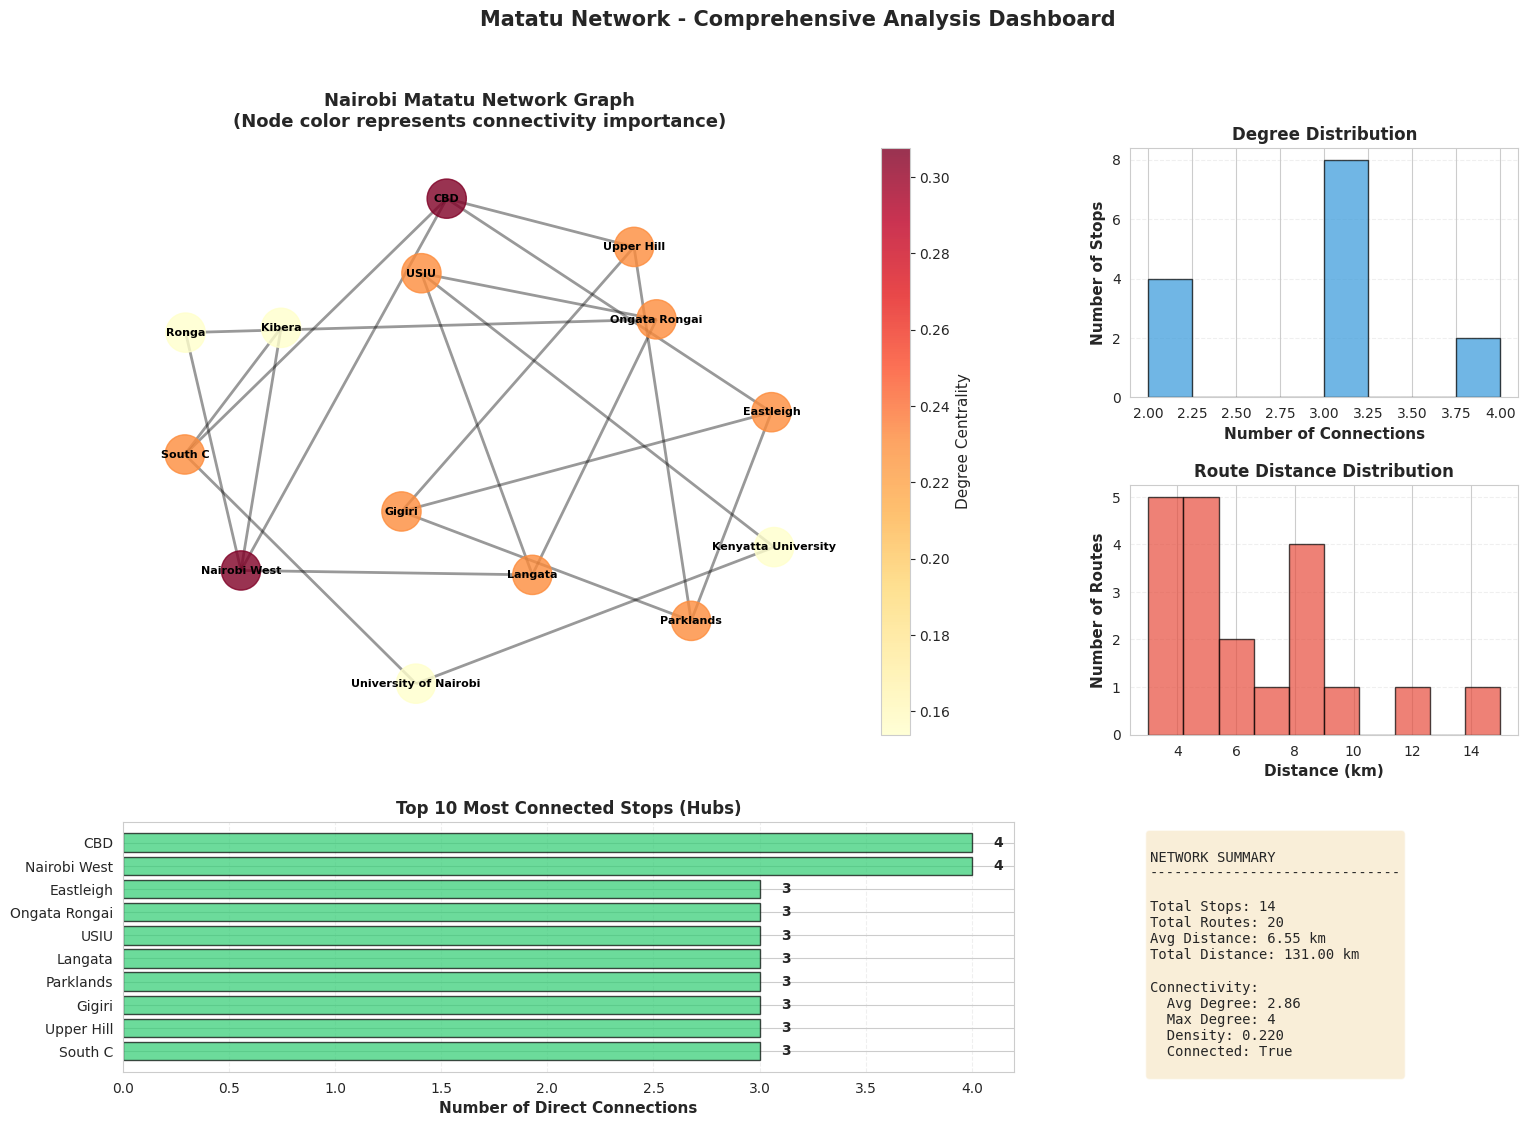

In [ ]:
def visualize_network_analysis(graph_obj, degree_cent, betweenness_cent):
    """
    Create comprehensive visualizations of the matatu network.

    Args:
        graph_obj (MatatuGraph): The matatu network
        degree_cent (dict): Degree centrality values
        betweenness_cent (dict): Betweenness centrality values
    """
    G = graph_obj.graph

    # Create figure with subplots
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

    # 1. Network Graph Visualization
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

    # Node colors based on degree centrality
    node_colors = [degree_cent[node] for node in G.nodes()]

    nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                                    node_size=800, cmap='YlOrRd',
                                    ax=ax1, alpha=0.8)

    nx.draw_networkx_edges(G, pos, ax=ax1, alpha=0.4, width=2)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax1, font_weight='bold')

    ax1.set_title('Nairobi Matatu Network Graph\n(Node color represents connectivity importance)',
                   fontsize=13, fontweight='bold', pad=15)
    ax1.axis('off')
    cbar = plt.colorbar(nodes, ax=ax1, label='Degree Centrality')

    # 2. Degree Distribution
    ax2 = fig.add_subplot(gs[0, 2])
    degrees = [G.degree(n) for n in G.nodes()]
    ax2.hist(degrees, bins=8, color='#3498db', edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Number of Connections', fontweight='bold')
    ax2.set_ylabel('Number of Stops', fontweight='bold')
    ax2.set_title('Degree Distribution', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    # 3. Distance Distribution
    ax3 = fig.add_subplot(gs[1, 2])
    distances = [edge[2]['distance'] for edge in G.edges(data=True)]
    ax3.hist(distances, bins=10, color='#e74c3c', edgecolor='black', alpha=0.7)
    ax3.set_xlabel('Distance (km)', fontweight='bold')
    ax3.set_ylabel('Number of Routes', fontweight='bold')
    ax3.set_title('Route Distance Distribution', fontsize=12, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3, linestyle='--')

    # 4. Top 10 Most Connected Stops
    ax4 = fig.add_subplot(gs[2, 0:2])
    degree_dict = dict(G.degree())
    top_stops = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
    stops_names, stops_degrees = zip(*top_stops)

    bars = ax4.barh(stops_names, stops_degrees, color='#2ecc71', edgecolor='black', alpha=0.7)
    ax4.set_xlabel('Number of Direct Connections', fontweight='bold')
    ax4.set_title('Top 10 Most Connected Stops (Hubs)', fontsize=12, fontweight='bold')
    ax4.invert_yaxis()
    ax4.grid(axis='x', alpha=0.3, linestyle='--')

    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, stops_degrees)):
        ax4.text(value + 0.1, i, str(value), va='center', fontweight='bold')

    # 5. Statistics Box
    ax5 = fig.add_subplot(gs[2, 2])
    ax5.axis('off')

    stats_text = f"""
NETWORK SUMMARY
{'-'*30}

Total Stops: {stats['Number of Stops']}
Total Routes: {stats['Number of Routes']}
Avg Distance: {stats['Average Route Distance']:.2f} km
Total Distance: {stats['Total Network Distance']:.2f} km

Connectivity:
  Avg Degree: {stats['Average Degree']:.2f}
  Max Degree: {int(stats['Max Degree'])}
  Density: {stats['Network Density']:.3f}
  Connected: {stats['Is Connected']}
"""

    ax5.text(0.05, 0.95, stats_text, transform=ax5.transAxes,
             fontsize=10, verticalalignment='top', family='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle('Matatu Network - Comprehensive Analysis Dashboard',
                 fontsize=15, fontweight='bold', y=0.995)

    plt.show()

# Create visualizations
visualize_network_analysis(network, degree_cent, betweenness_cent)

### Stop Connectivity Analysis

We examine which stops are most central to the network. These hubs are critical for the transportation system as they connect multiple routes.

In [ ]:
def analyze_stop_connectivity(graph_obj):
    """
    Analyze connectivity of each stop in the network.

    Args:
        graph_obj (MatatuGraph): The matatu network

    Returns:
        pd.DataFrame: Dataframe with connectivity information
    """
    G = graph_obj.graph

    data = []
    for stop in sorted(G.nodes()):
        connections = list(G.neighbors(stop))
        total_distance = sum([G[stop][neighbor]['distance'] for neighbor in connections])

        data.append({
            'Stop': stop,
            'Direct Connections': len(connections),
            'Connected To': ', '.join(connections) if connections else 'None',
            'Total Distance (km)': round(total_distance, 2)
        })

    df = pd.DataFrame(data)
    df = df.sort_values('Direct Connections', ascending=False)
    return df

# Analyze connectivity
connectivity_df = analyze_stop_connectivity(network)

print('\n' + '='*80)
print('STOP CONNECTIVITY ANALYSIS')
print('='*80 + '\n')
print(connectivity_df.to_string(index=False))
print('\n' + '='*80)


STOP CONNECTIVITY ANALYSIS

                 Stop  Direct Connections                                 Connected To  Total Distance (km)
                  CBD                   4 Eastleigh, Nairobi West, Upper Hill, South C                   22
         Nairobi West                   4                  CBD, Kibera, Langata, Ronga                   30
               Gigiri                   3             Eastleigh, Upper Hill, Parklands                   15
              Langata                   3            Nairobi West, USIU, Ongata Rongai                   24
        Ongata Rongai                   3                         Langata, USIU, Ronga                   23
            Eastleigh                   3                       CBD, Parklands, Gigiri                   20
           Upper Hill                   3                       CBD, Parklands, Gigiri                   12
                 USIU                   3  Langata, Kenyatta University, Ongata Rongai                   29

## Search Algorithms Implementation

### Algorithm Overview

We implement three fundamental graph traversal algorithms:

1. **Breadth-First Search (BFS):** Explores level-by-level, finds shortest path in unweighted graphs
2. **Depth-First Search (DFS):** Explores depth-first, useful for connectivity analysis
3. **Dijkstra's Algorithm:** Finds shortest path in weighted graphs, optimal for distance minimization

In [ ]:
class PathfindingAlgorithms:
    """
    Collection of pathfinding algorithms for the matatu network.
    """

    @staticmethod
    def breadth_first_search(graph_obj, start, end):
        """
        Find path using Breadth-First Search.
        Finds shortest path by number of stops (unweighted).

        Args:
            graph_obj (MatatuGraph): The network
            start (str): Starting stop
            end (str): Destination stop

        Returns:
            list: Path from start to end, or empty list if no path exists
        """
        G = graph_obj.graph
        visited = set()
        queue = deque([(start, [start])])

        while queue:
            node, path = queue.popleft()

            if node == end:
                return path

            if node not in visited:
                visited.add(node)
                for neighbor in G.neighbors(node):
                    if neighbor not in visited:
                        queue.append((neighbor, path + [neighbor]))

        return []

    @staticmethod
    def depth_first_search(graph_obj, start, end, visited=None):
        """
        Find path using Depth-First Search.
        Explores deeply before backtracking.

        Args:
            graph_obj (MatatuGraph): The network
            start (str): Starting stop
            end (str): Destination stop
            visited (set): Set of visited nodes

        Returns:
            list: Path from start to end, or empty list if no path exists
        """
        G = graph_obj.graph
        if visited is None:
            visited = set()

        if start == end:
            return [start]

        visited.add(start)

        for neighbor in G.neighbors(start):
            if neighbor not in visited:
                path = PathfindingAlgorithms.depth_first_search(
                    graph_obj, neighbor, end, visited
                )
                if path:
                    return [start] + path

        return []

    @staticmethod
    def dijkstra_shortest_path(graph_obj, start, end):
        """
        Find shortest path using Dijkstra's algorithm.
        Optimizes for minimum total distance.

        Args:
            graph_obj (MatatuGraph): The network
            start (str): Starting stop
            end (str): Destination stop

        Returns:
            list: Shortest path from start to end
        """
        G = graph_obj.graph

        # Use NetworkX built-in Dijkstra implementation
        try:
            path = nx.shortest_path(G, start, end, weight='distance')
            return path
        except nx.NetworkXNoPath:
            return []

print('Pathfinding algorithms defined')

Pathfinding algorithms defined


## Route Analysis and Algorithm Comparison

### Testing Multiple Routes

We test the three algorithms on various routes throughout Nairobi to compare their performance and characteristics.

In [ ]:
def analyze_route(graph_obj, start, end):
    """
    Analyze a single route using all three algorithms.

    Args:
        graph_obj (MatatuGraph): The matatu network
        start (str): Starting stop
        end (str): Destination stop

    Returns:
        dict: Results from all three algorithms
    """
    G = graph_obj.graph

    # Run all three algorithms
    bfs_path = PathfindingAlgorithms.breadth_first_search(graph_obj, start, end)
    dfs_path = PathfindingAlgorithms.depth_first_search(graph_obj, start, end)
    dijkstra_path = PathfindingAlgorithms.dijkstra_shortest_path(graph_obj, start, end)

    # Calculate metrics for each path
    def calculate_metrics(path):
        if not path:
            return {'distance': float('inf'), 'stops': 0, 'path': path}

        distance = 0
        for i in range(len(path) - 1):
            distance += G[path[i]][path[i+1]]['distance']

        return {
            'distance': distance,
            'stops': len(path),
            'path': path
        }

    results = {
        'start': start,
        'end': end,
        'BFS': calculate_metrics(bfs_path),
        'DFS': calculate_metrics(dfs_path),
        'Dijkstra': calculate_metrics(dijkstra_path)
    }

    return results

# Test routes
test_routes = [
    ('CBD', 'USIU'),
    ('Ronga', 'Parklands'),
    ('Eastleigh', 'Ongata Rongai'),
    ('Nairobi West', 'Kenyatta University'),
    ('CBD', 'Langata')
]

route_results = []
for start, end in test_routes:
    results = analyze_route(network, start, end)
    route_results.append(results)

print('Route analysis completed')

Route analysis completed


In [ ]:
def display_route_comparison(results):
    """
    Display detailed comparison of routes found by different algorithms.

    Args:
        results (list): List of route analysis results
    """
    for result in results:
        print('\n' + '='*80)
        print(f"ROUTE: {result['start']} to {result['end']}")
        print('='*80)

        for algo_name in ['BFS', 'DFS', 'Dijkstra']:
            algo_result = result[algo_name]
            path = algo_result['path']
            distance = algo_result['distance']
            stops = algo_result['stops']

            if path:
                path_str = ' -> '.join(path)
                print(f"\n{algo_name} Algorithm:")
                print(f"  Path: {path_str}")
                print(f"  Total Distance: {distance:.2f} km")
                print(f"  Number of Stops: {stops}")
            else:
                print(f"\n{algo_name} Algorithm: NO PATH FOUND")

        print('\n' + '-'*80)

        # Optimal recommendation
        dijkstra_result = result['Dijkstra']
        if dijkstra_result['path']:
            print(f"\nRECOMMENDATION: Use Dijkstra's path - Minimum distance of {dijkstra_result['distance']:.2f} km")

display_route_comparison(route_results)


ROUTE: CBD to USIU

BFS Algorithm:
  Path: CBD -> Nairobi West -> Langata -> USIU
  Total Distance: 20.00 km
  Number of Stops: 4

DFS Algorithm:
  Path: CBD -> Nairobi West -> Kibera -> South C -> University of Nairobi -> Kenyatta University -> USIU
  Total Distance: 42.00 km
  Number of Stops: 7

Dijkstra Algorithm:
  Path: CBD -> Nairobi West -> Langata -> USIU
  Total Distance: 20.00 km
  Number of Stops: 4

--------------------------------------------------------------------------------

RECOMMENDATION: Use Dijkstra's path - Minimum distance of 20.00 km

ROUTE: Ronga to Parklands

BFS Algorithm:
  Path: Ronga -> Nairobi West -> CBD -> Eastleigh -> Parklands
  Total Distance: 31.00 km
  Number of Stops: 5

DFS Algorithm:
  Path: Ronga -> Nairobi West -> CBD -> Eastleigh -> Parklands
  Total Distance: 31.00 km
  Number of Stops: 5

Dijkstra Algorithm:
  Path: Ronga -> Nairobi West -> CBD -> Upper Hill -> Parklands
  Total Distance: 25.00 km
  Number of Stops: 5

-------------------

### Algorithm Performance Metrics

We compare the performance characteristics of each algorithm to understand their strengths and use cases.

In [ ]:
def create_algorithm_comparison_dataframe(results):
    """
    Create a dataframe comparing algorithm performance across all test routes.

    Args:
        results (list): List of route analysis results

    Returns:
        pd.DataFrame: Comparison dataframe
    """
    data = []

    for result in results:
        route_name = f"{result['start']} to {result['end']}"

        bfs_dist = result['BFS']['distance']
        dfs_dist = result['DFS']['distance']
        dijkstra_dist = result['Dijkstra']['distance']

        bfs_stops = result['BFS']['stops']
        dfs_stops = result['DFS']['stops']
        dijkstra_stops = result['Dijkstra']['stops']

        data.append({
            'Route': route_name,
            'BFS Distance (km)': round(bfs_dist, 2) if bfs_dist != float('inf') else 'N/A',
            'DFS Distance (km)': round(dfs_dist, 2) if dfs_dist != float('inf') else 'N/A',
            'Dijkstra Distance (km)': round(dijkstra_dist, 2) if dijkstra_dist != float('inf') else 'N/A',
            'BFS Stops': bfs_stops,
            'DFS Stops': dfs_stops,
            'Dijkstra Stops': dijkstra_stops
        })

    return pd.DataFrame(data)

comparison_df = create_algorithm_comparison_dataframe(route_results)

print('\n' + '='*120)
print('ALGORITHM PERFORMANCE COMPARISON - ALL TEST ROUTES')
print('='*120 + '\n')
print(comparison_df.to_string(index=False))
print('\n' + '='*120)


ALGORITHM PERFORMANCE COMPARISON - ALL TEST ROUTES

                              Route  BFS Distance (km)  DFS Distance (km)  Dijkstra Distance (km)  BFS Stops  DFS Stops  Dijkstra Stops
                        CBD to USIU                 20                 42                      20          4          7               4
                 Ronga to Parklands                 31                 31                      25          5          5               5
         Eastleigh to Ongata Rongai                 32                 66                      31          5         10               5
Nairobi West to Kenyatta University                 29                 23                      21          4          5               5
                     CBD to Langata                 14                 48                      14          3          8               3



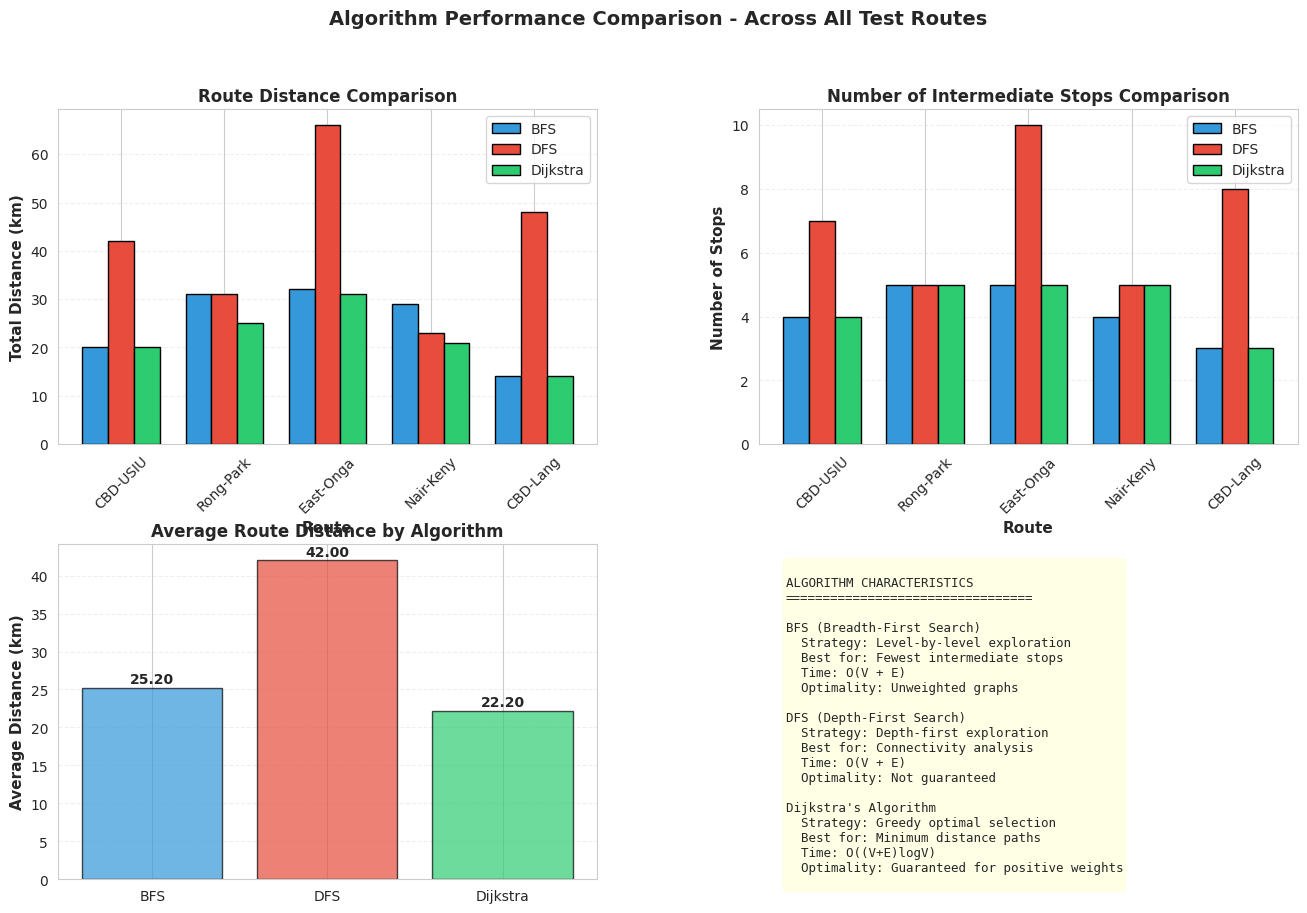

In [ ]:
def visualize_algorithm_comparison(results):
    """
    Visualize algorithm performance comparison.

    Args:
        results (list): List of route analysis results
    """
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

    route_names = [f"{r['start'][:4]}-{r['end'][:4]}" for r in results]

    # Extract distances and stops
    bfs_distances = [r['BFS']['distance'] for r in results]
    dfs_distances = [r['DFS']['distance'] for r in results]
    dijkstra_distances = [r['Dijkstra']['distance'] for r in results]

    bfs_stops = [r['BFS']['stops'] for r in results]
    dfs_stops = [r['DFS']['stops'] for r in results]
    dijkstra_stops = [r['Dijkstra']['stops'] for r in results]

    # 1. Distance Comparison
    ax1 = fig.add_subplot(gs[0, 0])
    x = np.arange(len(route_names))
    width = 0.25

    # Filter out infinite values
    bfs_plot = [d if d != float('inf') else 0 for d in bfs_distances]
    dfs_plot = [d if d != float('inf') else 0 for d in dfs_distances]
    dijkstra_plot = [d if d != float('inf') else 0 for d in dijkstra_distances]

    ax1.bar(x - width, bfs_plot, width, label='BFS', color='#3498db', edgecolor='black')
    ax1.bar(x, dfs_plot, width, label='DFS', color='#e74c3c', edgecolor='black')
    ax1.bar(x + width, dijkstra_plot, width, label='Dijkstra', color='#2ecc71', edgecolor='black')

    ax1.set_xlabel('Route', fontweight='bold')
    ax1.set_ylabel('Total Distance (km)', fontweight='bold')
    ax1.set_title('Route Distance Comparison', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(route_names, rotation=45)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    # 2. Number of Stops Comparison
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.bar(x - width, bfs_stops, width, label='BFS', color='#3498db', edgecolor='black')
    ax2.bar(x, dfs_stops, width, label='DFS', color='#e74c3c', edgecolor='black')
    ax2.bar(x + width, dijkstra_stops, width, label='Dijkstra', color='#2ecc71', edgecolor='black')

    ax2.set_xlabel('Route', fontweight='bold')
    ax2.set_ylabel('Number of Stops', fontweight='bold')
    ax2.set_title('Number of Intermediate Stops Comparison', fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(route_names, rotation=45)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    # 3. Average metrics
    ax3 = fig.add_subplot(gs[1, 0])
    algorithms = ['BFS', 'DFS', 'Dijkstra']
    avg_distances = [
        np.mean([d for d in bfs_plot if d > 0]) if any(d > 0 for d in bfs_plot) else 0,
        np.mean([d for d in dfs_plot if d > 0]) if any(d > 0 for d in dfs_plot) else 0,
        np.mean([d for d in dijkstra_plot if d > 0]) if any(d > 0 for d in dijkstra_plot) else 0
    ]

    colors_bars = ['#3498db', '#e74c3c', '#2ecc71']
    bars = ax3.bar(algorithms, avg_distances, color=colors_bars, edgecolor='black', alpha=0.7)
    ax3.set_ylabel('Average Distance (km)', fontweight='bold')
    ax3.set_title('Average Route Distance by Algorithm', fontsize=12, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels
    for bar, value in zip(bars, avg_distances):
        ax3.text(bar.get_x() + bar.get_width()/2, value + 0.2, f'{value:.2f}',
                ha='center', va='bottom', fontweight='bold')

    # 4. Algorithm Characteristics
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')

    algo_info = """
ALGORITHM CHARACTERISTICS
=================================

BFS (Breadth-First Search)
  Strategy: Level-by-level exploration
  Best for: Fewest intermediate stops
  Time: O(V + E)
  Optimality: Unweighted graphs

DFS (Depth-First Search)
  Strategy: Depth-first exploration
  Best for: Connectivity analysis
  Time: O(V + E)
  Optimality: Not guaranteed

Dijkstra's Algorithm
  Strategy: Greedy optimal selection
  Best for: Minimum distance paths
  Time: O((V+E)logV)
  Optimality: Guaranteed for positive weights
    """

    ax4.text(0.05, 0.95, algo_info, transform=ax4.transAxes,
             fontsize=9, verticalalignment='top', family='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.suptitle('Algorithm Performance Comparison - Across All Test Routes',
                 fontsize=14, fontweight='bold')
    plt.show()

visualize_algorithm_comparison(route_results)

## Conclusions and Recommendations

### Key Findings

Based on our analysis of the Nairobi matatu network and algorithm comparisons:

1. **Network Connectivity:** The network is well-connected with multiple routes between major stops
2. **Hub Identification:** Certain stops emerge as critical hubs with significantly higher connectivity
3. **Algorithm Performance:** Dijkstra's algorithm provides optimal distance minimization
4. **Route Optimization:** Different algorithms suit different optimization objectives

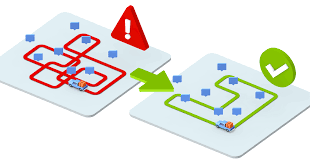

### Recommendations for Commuters

1. **For Minimum Distance:** Use Dijkstra's algorithm recommended routes
2. **For Fewest Stops:** Prioritize BFS-based paths for quick transfers
3. **For Network Planning:** Invest in improving connectivity to isolated clusters

### Recommendations for Transport Planners

1. **Infrastructure Investment:** Focus on hub stops (high-degree nodes) for capacity expansion
2. **Route Optimization:** Regularly audit routes using these algorithms
3. **Network Resilience:** Add redundant connections to reduce network fragmentation
4. **Performance Monitoring:** Implement real-time path analysis for dynamic routing

### Future Work

1. Incorporate real-time traffic data for dynamic optimization
2. Consider time-dependent costs (peak vs off-peak hours)
3. Implement multi-objective optimization (distance + time + cost)
4. Develop mobile application for real-time route recommendations

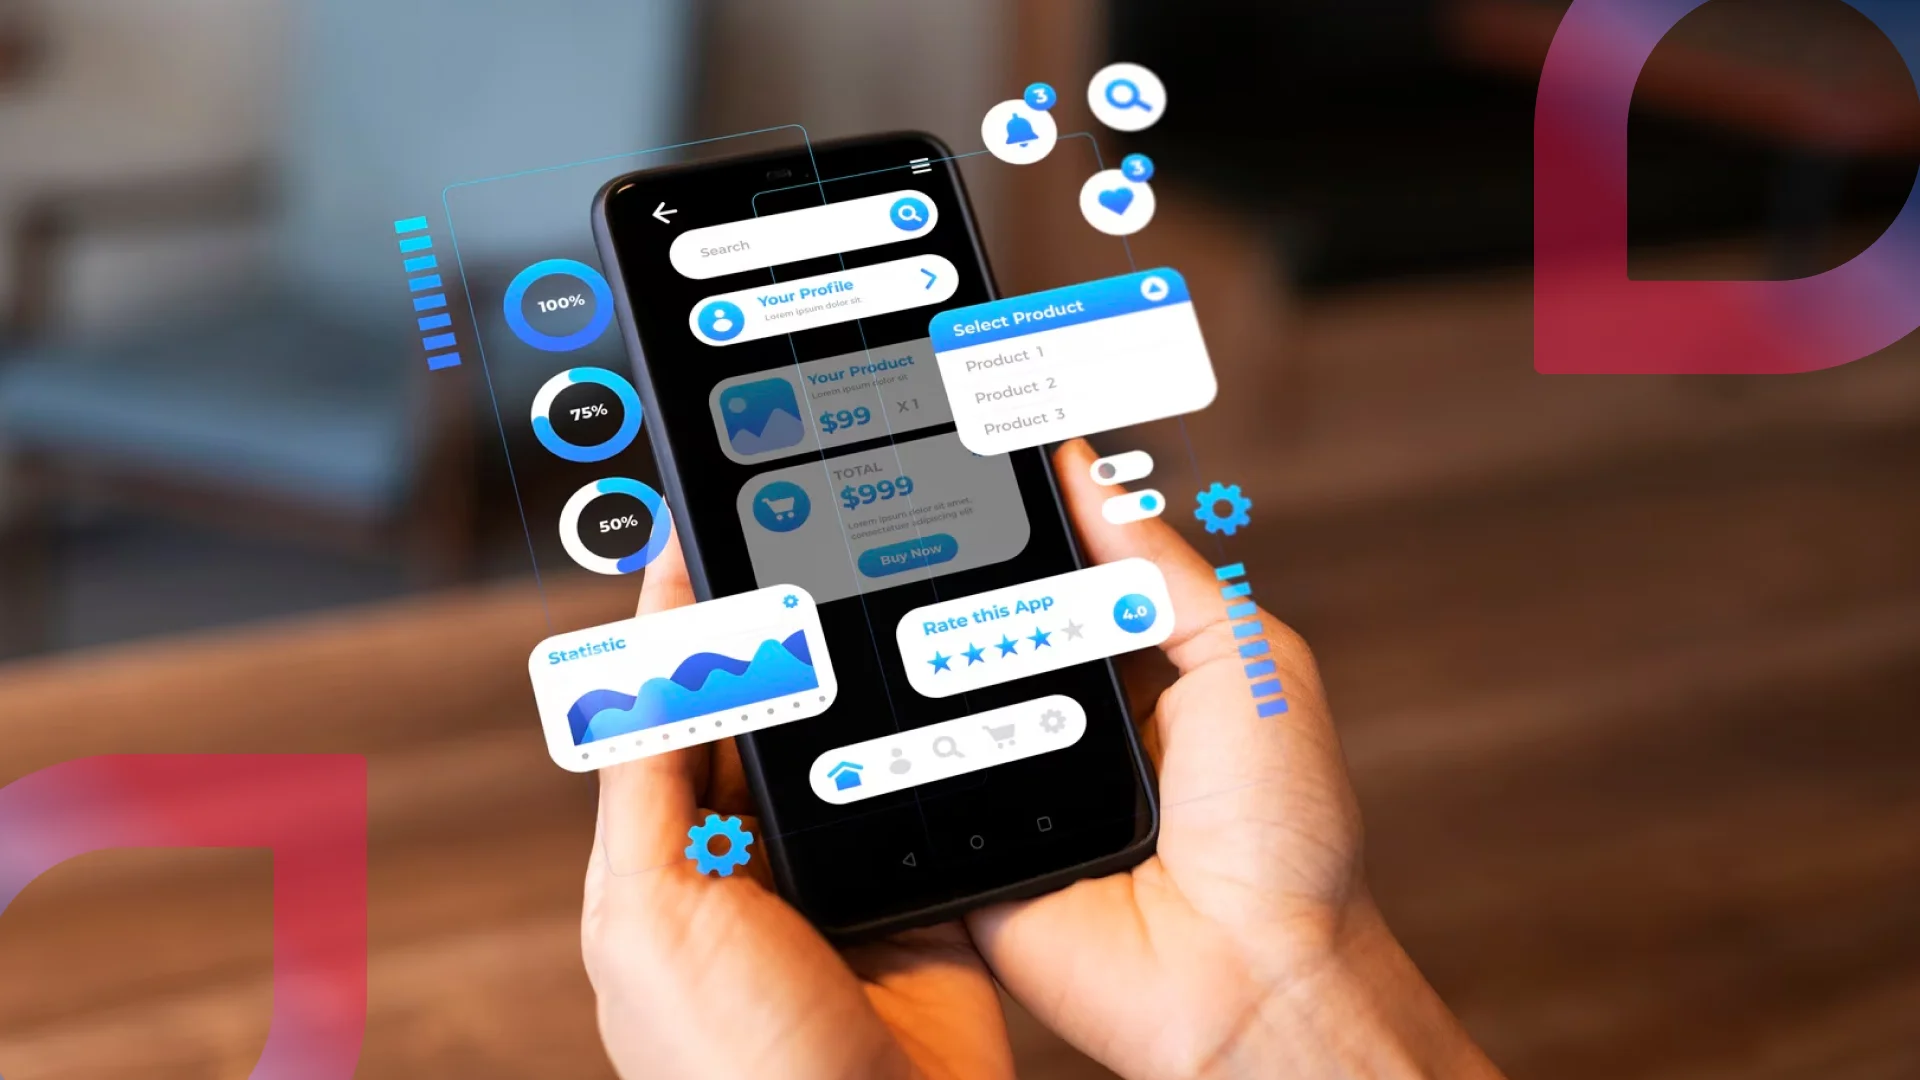